# IPL 2022 Capstone Project

##### The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.

#### These are some of the important columns that we'll focus on for meaningful insights in this project.

### column names: Variable Type



* **date:** string
* **venue:** string
* **stage:** string
* **team1:** string
* **team2:** string
* **toss_winner:** string
* **toss_decision:** string
* **first_ings_score:** integer
* **second_ings_score:** integer
* **match_winner:** string
* **won_by:** string
* **margin:** integer
* **player_of_the_match:** string
* **top_scorer:** string
* **highscore:** integer
* **best_bowling:** string
* **best_bowling_figure:** string
* **figure:** string


#### Loading the Libraries and dataset

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('IPL.csv')
df.head()


,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


#### Basic Information

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

##### Check the size of rows and columns of dataset

In [4]:
print(f"Your rows are {df.shape[0]} and your columns are {df.shape[1]}")

Your rows are 74 and your columns are 20


##### Now lets see how many colums have null values in total

In [6]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

### Now, here Comes some basic questions:

#####  1. Which team won the most matches?

Text(0.5, 1.0, 'Most match wins by team')

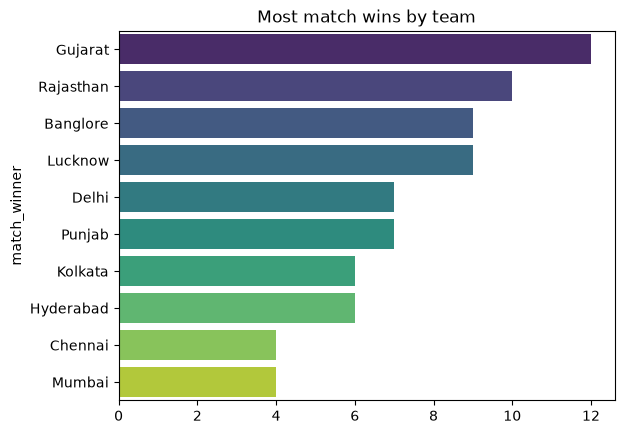

In [14]:
match_wins = df['match_winner'].value_counts()
sns.barplot(y=match_wins.index, x=match_wins.values, palette='viridis')
plt.title('Most match wins by team')

##### 2. Toss Decision Trends

Text(0.5, 1.0, 'Toss Decision Treds')

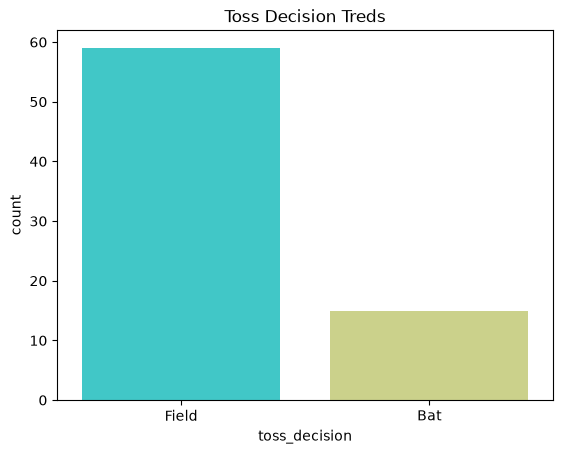

In [17]:
sns.countplot(x = df['toss_decision'], palette='rainbow')
plt.title('Toss Decision Treds')

##### 3. Toss Winner VS Match Winner

In [22]:
count = df[df['toss_winner'] == df['match_winner']] ['match_id'].count()
percentage = (count * 100)/df.shape[0]
print(percentage.round(2))

48.65


##### 4. How do teams wins. (Runs Vs Wickets)?

Text(0.5, 1.0, 'Won BY')

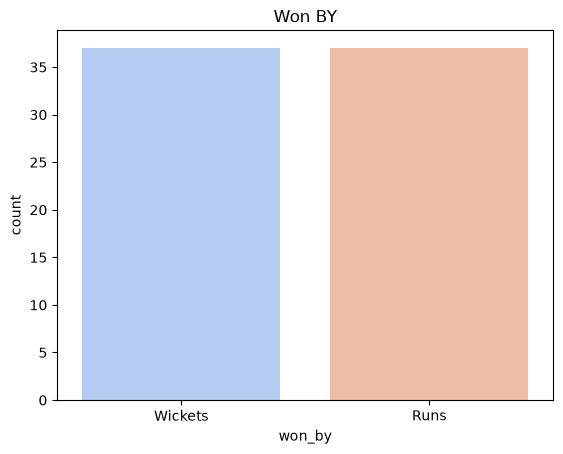

In [24]:
sns.countplot(x = df['won_by'], palette='coolwarm')
plt.title('Won BY')

#### Key Player Performances

##### 1. Most 'Player of the Match' Award?

In [ ]:
count = df['player_of_the_match'].value_counts().head(10)


player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Umesh Yadav          2
Wanindu Hasaranga    2
Avesh Khan           2
Dinesh Karthik       2
Quinton de Kock      2
Shubman Gill         2
Yuzvendra Chahal     2
Hardik Pandya        2
Name: count, dtype: int64

Text(0.5, 1.0, 'Top 10 Players with man of the match')

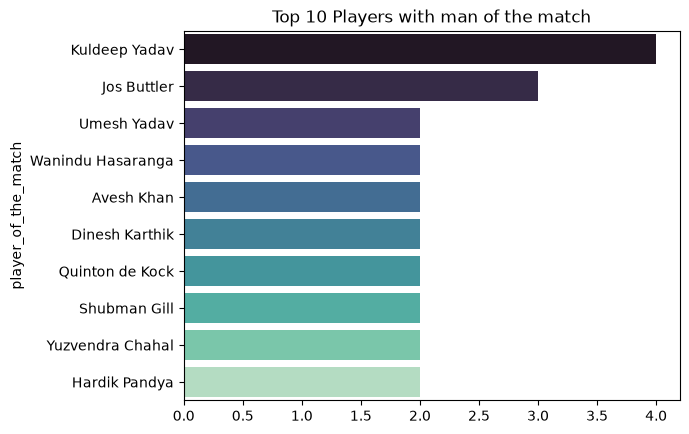

In [28]:
sns.barplot(x=count.values, y=count.index, palette='mako')
plt.title('Top 10 Players with man of the match')

#### 2. Top Scorers

In [32]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(5)
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
KL Rahul           351
Shubman Gill       288
Faf du Plessis     257
Name: highscore, dtype: int64

<Axes: ylabel='top_scorer'>

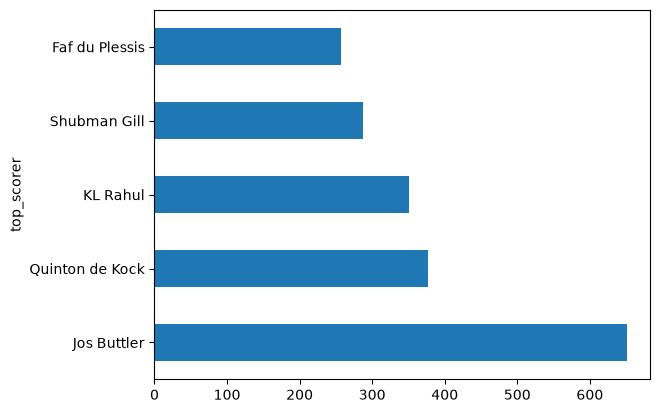

In [36]:
high.plot(kind='barh')

#### 10 Best Bowling Figures

Text(0.5, 1.0, 'Top 10 Bowling Figures')

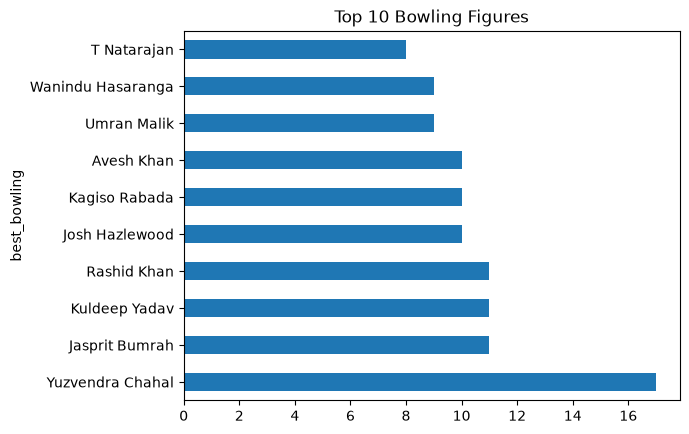

In [41]:
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x:x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype(int)
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers.plot(kind='barh')
plt.title("Top 10 Bowling Figures")

### Venue Analysis

##### Most Matches played by venues

In [43]:
venue_count = df['venue'].value_counts()
venue_count

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

Text(0.5, 1.0, 'Most Matches Played By Venues')

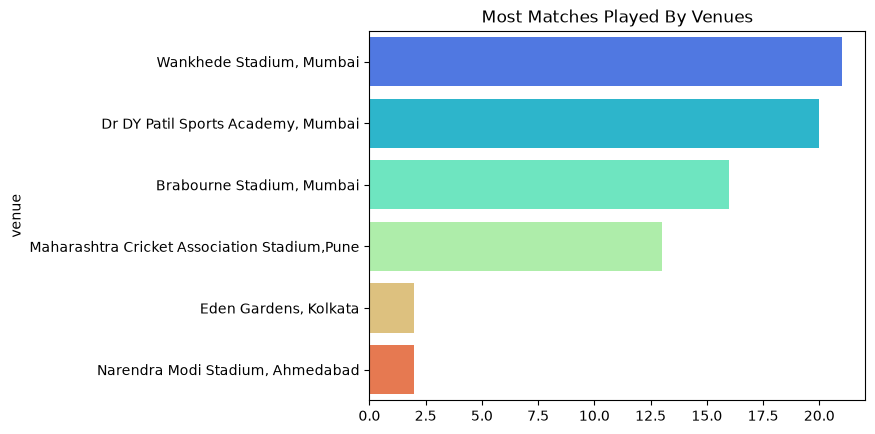

In [46]:
sns.barplot(y=venue_count.index, x=venue_count.values, palette='rainbow')
plt.title('Most Matches Played By Venues')

### Custom Questions & Insights

###### Q.01 Who won the highest margin by runs?

In [49]:
df[df['won_by'] == 'Runs'].sort_values(by='margin', ascending=False).head(4)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91
52,Lucknow,75
53,Banglore,67
56,Gujarat,62


###### Q.02. Which player had the highest individual score?

In [56]:
df[df['highscore'] == df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


###### Q.03 Which bowlers had the best bowling figures?

In [57]:
df[df['highest_wickets'] == df['highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10


### Final Conclusion

* **Team Performance:** Identified the teams that won the most matches in IPL 2022.
* **Toss Analysis:** Examined the most common toss decisions and their trends.
* **Toss vs Match:** Compared toss winners with match winners to see how often they were the same.
* **Match Results:** Analyzed whether teams mainly won by **runs or wickets**.
* **Player Performance:** Identified players who received the most **Player of the Match** awards.
* **Batting Performance:** Found the top run scorers and players with the highest individual scores.
* **Bowling Performance:** Identified bowlers with the best bowling figures and highest wickets.
* **Venue Analysis:** Found the venues where the most IPL 2022 matches were played.
* **Overall Insight:** The project shows how **Pandas, NumPy, Matplotlib, and Seaborn** can be used to analyze cricket data and discover meaningful patterns.


# GOOD WORK